In [7]:
!pip install -q stable-baselines3 huggingface_hub gymnasium[classic-control] matplotlib pillow

zsh:1: no matches found: gymnasium[classic-control]


In [8]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from huggingface_hub import hf_hub_download
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [16]:
import warnings
warnings.filterwarnings("ignore")

In [17]:
repo_id = "sb3/ppo-CartPole-v1"
filename = "ppo-CartPole-v1.zip"

model_path = hf_hub_download(
    repo_id=repo_id,
    filename=filename
)

model = PPO.load(model_path)

print("Модель успішно завантажена:")
print(repo_id)

Модель успішно завантажена:
sb3/ppo-CartPole-v1


In [18]:
env = gym.make("CartPole-v1", render_mode="rgb_array")
observation, info = env.reset(seed=42)
print("Початковий стан:")
print(observation)

Початковий стан:
[ 0.0273956  -0.00611216  0.03585979  0.0197368 ]


In [22]:
frames = []
actions = []
rewards = []

observation, info = env.reset(seed=42)

max_steps = 200

for step in range(max_steps):
    action, _ = model.predict(observation, deterministic=True)
    observation, reward, terminated, truncated, info = env.step(action)
    frame = env.render()
    frames.append(frame)

    actions.append(int(action))
    rewards.append(float(reward))

    if terminated or truncated:
        break

env.close()

print("Кількість отриманих кадрів:", len(frames))
print("Сумарна винагорода:", sum(rewards))
print("Перші 10 дій:", actions[:10])

Кількість отриманих кадрів: 200
Сумарна винагорода: 200.0
Перші 10 дій: [1, 0, 1, 0, 1, 1, 0, 0, 1, 1]


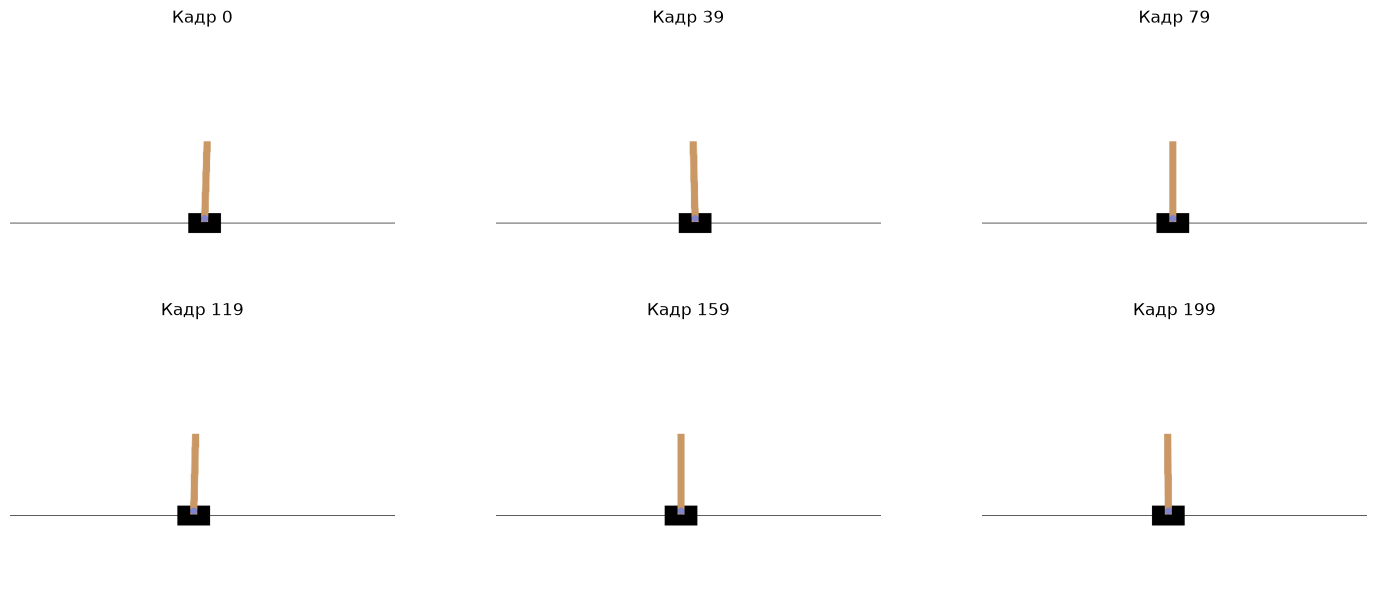

In [23]:
number_to_show = min(6, len(frames))
indexes = np.linspace(0, len(frames) - 1, number_to_show, dtype=int)
plt.figure(figsize=(15, 6))

for i, frame_index in enumerate(indexes):
    plt.subplot(2, 3, i + 1)
    plt.imshow(frames[frame_index])
    plt.title(f"Кадр {frame_index}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
frame_order = [0, 10, 25, 5, 40, 15, 60, 30, 80, 50, 100, 70, 120]
frame_order = [i for i in frame_order if i < len(frames)]
custom_frames = [frames[i] for i in frame_order]

print("Моя послідовність кадрів:")
print(frame_order)

Моя послідовність кадрів:
[0, 10, 25, 5, 40, 15, 60, 30, 80, 50, 100, 70, 120]


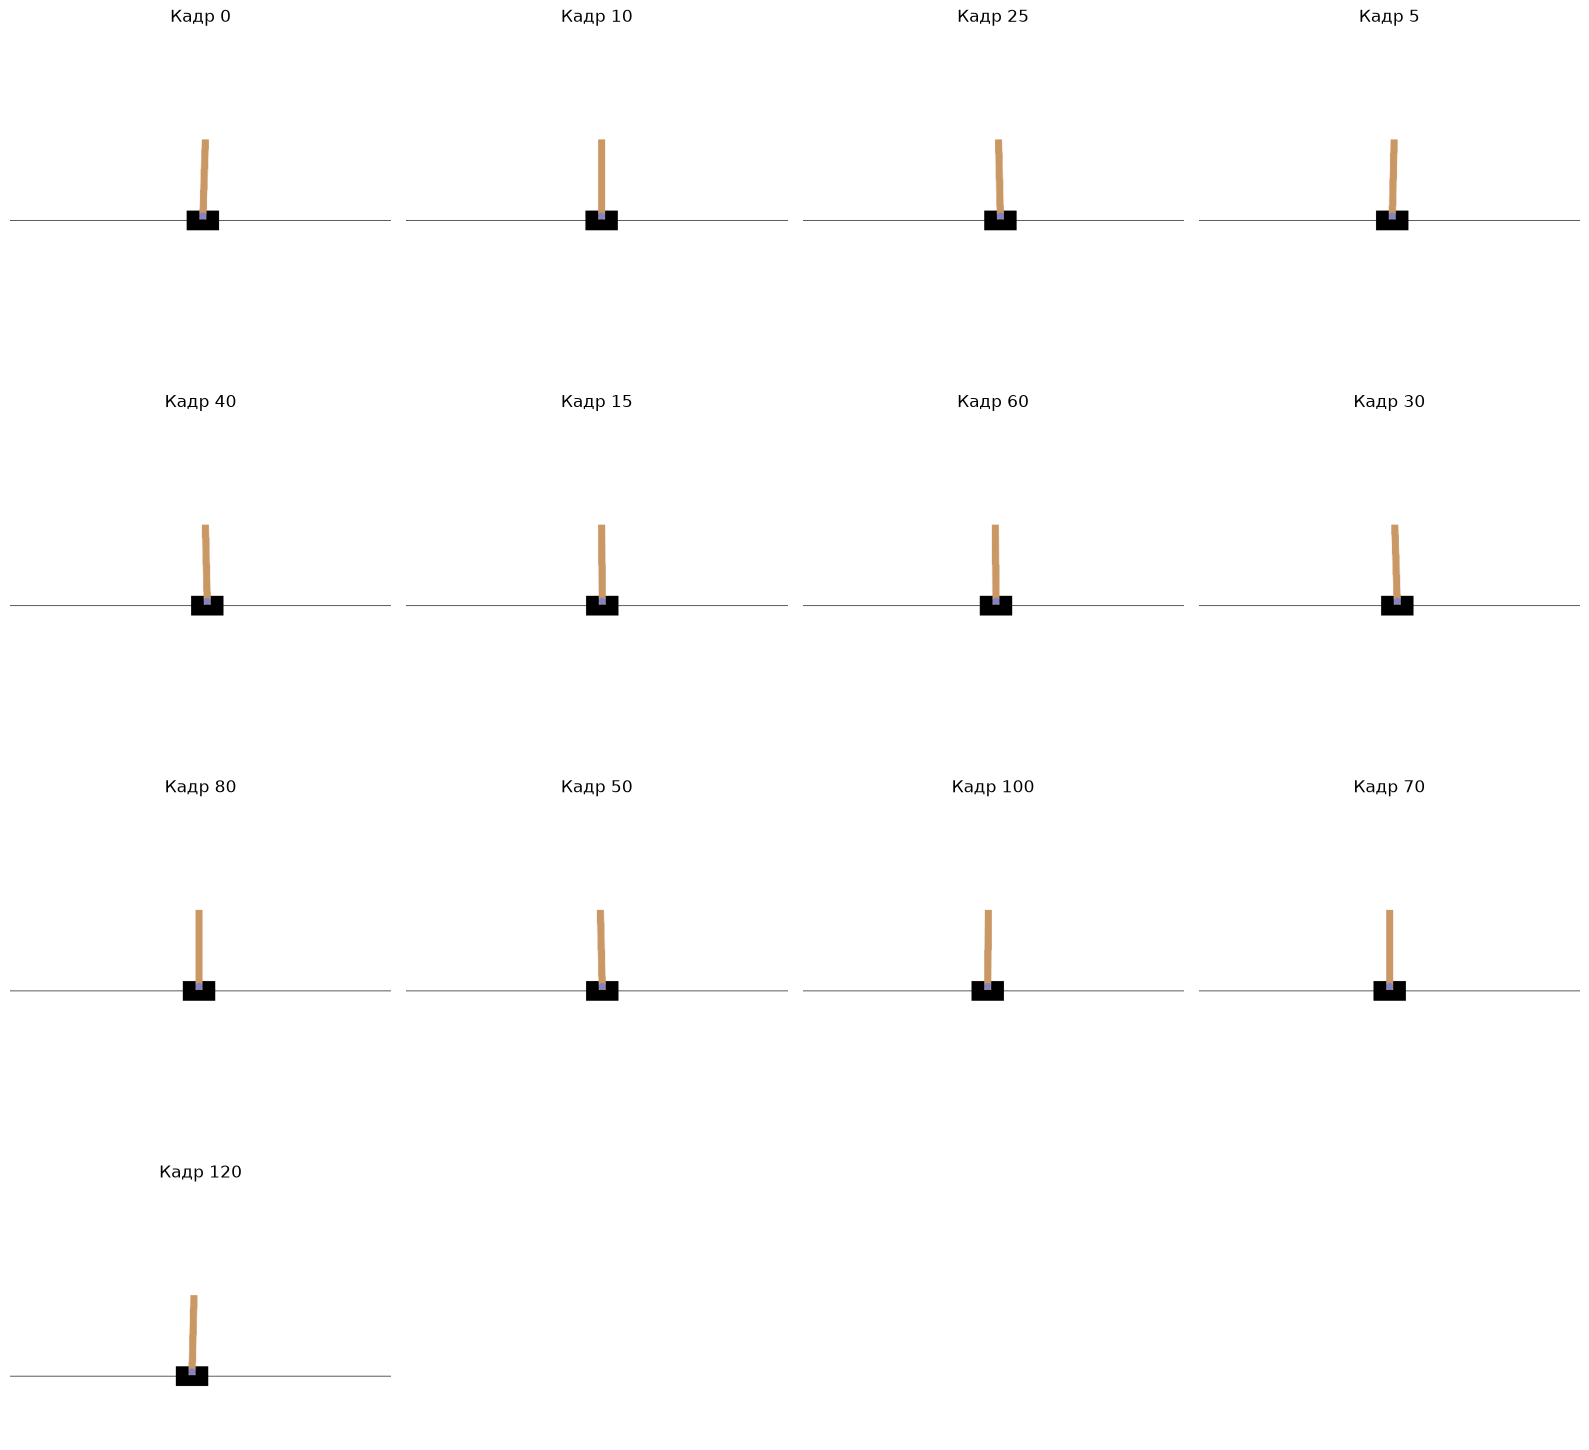

In [25]:
if len(custom_frames) == 0:
    print("Немає кадрів для відображення.")
else:
    cols = 4
    rows = int(np.ceil(len(custom_frames) / cols))

    plt.figure(figsize=(16, 4 * rows))

    for i, (frame_index, frame) in enumerate(zip(frame_order, custom_frames)):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(frame)
        plt.title(f"Кадр {frame_index}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [26]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.axis("off")
image = ax.imshow(custom_frames[0])
def update(i):
    image.set_data(custom_frames[i])
    ax.set_title(f"Кадр {frame_order[i]}")
    return [image]

animation = FuncAnimation(
    fig,
    update,
    frames=len(custom_frames),
    interval=500,
    blit=False
)

plt.close(fig)
HTML(animation.to_jshtml())

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.axis("off")
image = ax.imshow(frames[0])
def update_full(i):
    image.set_data(frames[i])
    ax.set_title(f"Step {i}, action = {actions[i]}")
    return [image]

full_animation = FuncAnimation(
    fig,
    update_full,
    frames=len(frames),
    interval=50,
    blit=False
)

plt.close(fig)
HTML(full_animation.to_jshtml())